The notebooks goal is to explore and aggregate the 'previous application' table to improve models performance. As in previous instances, raw variables and basic processing can be found in [notebooks\nb7_previous_applications.ipynb](notebooks\nb7_previous_applications.ipynb).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import joblib

import matplotlib.pyplot as plt

from helpers import preprocessing, submissions, preprocessing

from helpers.utils import (
    stats_helper,
    plotting_helper,
    unsupervised_helper,
    aggregator_helper,
)
from helpers.model_builders import bureau_preparation

from helpers.utils.cleaner_helper import plot_categorical_dist, plot_numeric_dist

from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
import hdbscan
import importlib

In [2]:
prev_app = preprocessing.load_pkl_to_preprocessor("previous_application")
display(prev_app.convert_all("category").info(show_counts=True))
prev_app.data[["SK_ID_PREV", "SK_ID_CURR"]] = prev_app.data[
    ["SK_ID_PREV", "SK_ID_CURR"]
].astype(str)
print(prev_app.column_structure)
prev_app = prev_app.data

Loading tables: ['previous_application.csv']
loaded previous_application with shape (1670214, 37)
dict_keys(['credit_status', 'bureau_overdue', 'time_variables', 'bureau', 'bureau_balance', 'pos_cash_balance', 'balance_limits', 'drawings_payments', 'contract_installments', 'credit_card_balance', 'previous_application', 'installments_payments'])
No missing columns.
Unexpected columns: ['SK_ID_CURR', 'SK_ID_PREV']
No missing columns.
Unexpected columns: ['SK_ID_CURR', 'SK_ID_PREV']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype   
---  ------                       --------------    -----   
 0   SK_ID_PREV                   1670214 non-null  int64   
 1   SK_ID_CURR                   1670214 non-null  object  
 2   NAME_CONTRACT_TYPE           1670214 non-null  category
 3   AMT_ANNUITY                  1297979 non-null  float64 
 4   AMT_APPLICATION              16

None

{'application_basics': ['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START'], 'application_status_rates': ['FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON'], 'client_product_info': ['NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY', 'CNT_PAYMENT', 'NAME_YIELD_GROUP'], 'loan_timeline_insurance': ['PRODUCT_COMBINATION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL']}


# EDA

Text(0.5, 1.0, 'Distribution of previous applications per client')

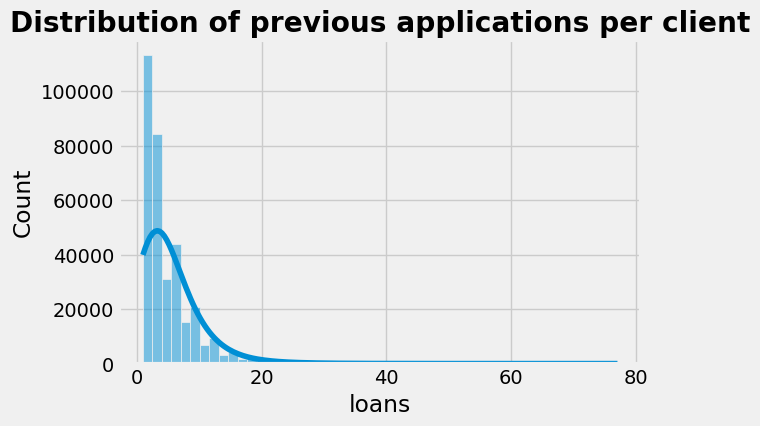

In [3]:
applied_for = prev_app.groupby("SK_ID_CURR").size().value_counts().reset_index()
applied_for.columns = ["loans", "previous applications"]
plt.figure(figsize=(6, 4))
sns.histplot(
    data=applied_for, x="loans", weights="previous applications", bins=50, kde=True
)
plt.title("Distribution of previous applications per client")

* People who have no applied previously are not listed.
* Majority of people have applied for less than 10 times.

,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,HOUR_APPR_PROCESS_START,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,DAYS_DECISION,SELLERPLACE_AREA,CNT_PAYMENT,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
AMT_ANNUITY,1.000000,0.808872,0.816429,0.267694,0.820895,-0.036201,-0.103878,0.141823,-0.202335,0.279051,-0.015027,0.394535,0.052839,-0.053295,-0.068877,0.082659,0.068022,0.283080
AMT_APPLICATION,0.808872,1.000000,0.975824,0.482776,0.999884,-0.014415,-0.072479,0.110001,-0.199733,0.133660,-0.007649,0.680630,0.074544,-0.049532,-0.084905,0.172627,0.148618,0.259219
AMT_CREDIT,0.816429,0.975824,1.000000,0.301284,0.993087,-0.021039,-0.188128,0.125106,-0.205158,0.133763,-0.009567,0.674278,-0.036813,0.002881,0.044031,0.224829,0.214320,0.263932
AMT_DOWN_PAYMENT,0.267694,0.482776,0.301284,1.000000,0.482776,0.016776,0.473935,0.016323,-0.115343,-0.024536,0.003533,0.031659,-0.001773,-0.013586,-0.000869,-0.031425,-0.030702,-0.042585
AMT_GOODS_PRICE,0.820895,0.999884,0.993087,0.482776,1.000000,-0.045267,-0.072479,0.110001,-0.199733,0.290422,-0.015842,0.672129,-0.024445,-0.021062,0.016883,0.211696,0.209296,0.243400
HOUR_APPR_PROCESS_START,-0.036201,-0.014415,-0.021039,0.016776,-0.045267,1.000000,0.025930,-0.027172,-0.045720,-0.039962,0.015671,-0.055511,0.014321,-0.002797,-0.016567,-0.018018,-0.018254,-0.117318
RATE_DOWN_PAYMENT,-0.103878,-0.072479,-0.188128,0.473935,-0.072479,0.025930,1.000000,-0.103373,-0.106143,-0.208742,-0.006489,-0.278875,-0.007969,-0.039178,-0.010934,-0.147562,-0.145461,-0.021633
RATE_INTEREST_PRIMARY,0.141823,0.110001,0.125106,0.016323,0.110001,-0.027172,-0.103373,1.000000,-0.001937,0.014037,0.159182,-0.019030,NaN,-0.017171,-0.000933,-0.010677,-0.011099,0.311938
RATE_INTEREST_PRIVILEGED,-0.202335,-0.199733,-0.205158,-0.115343,-0.199733,-0.045720,-0.106143,-0.001937,1.000000,0.631940,-0.066316,-0.057150,NaN,0.150904,0.030513,0.372214,0.378671,-0.067157
DAYS_DECISION,0.279051,0.133660,0.133763,-0.024536,0.290422,-0.039962,-0.208742,0.014037,0.631940,1.000000,-0.018382,0.246453,-0.012007,0.176711,0.089167,0.448549,0.400179,-0.028905


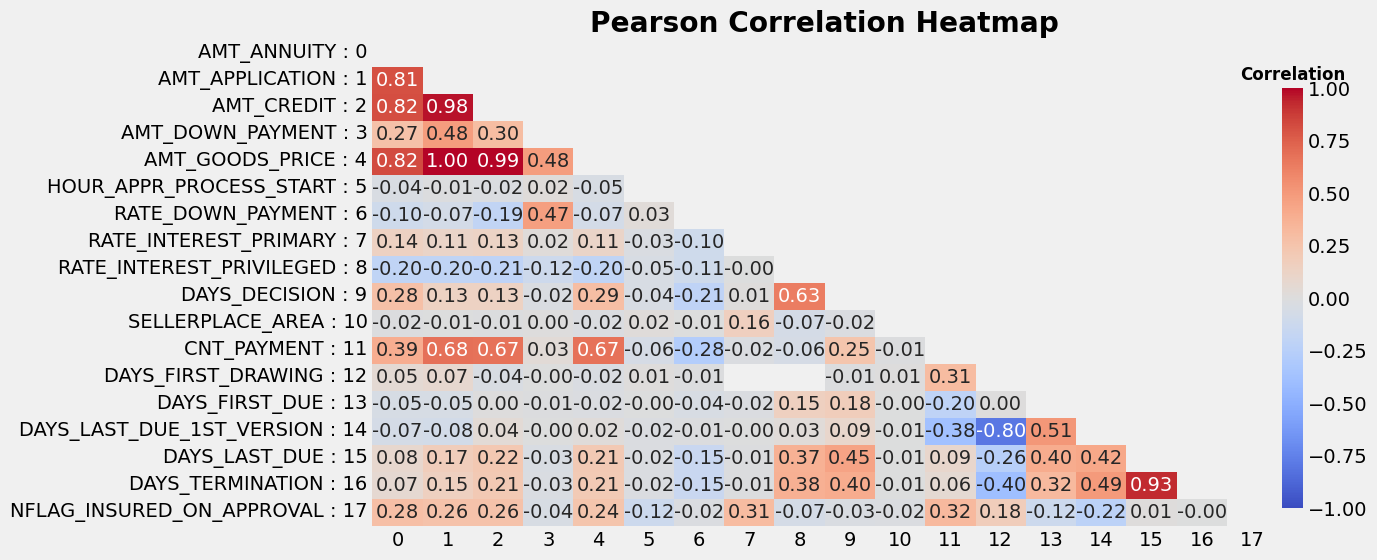

In [4]:
importlib.reload(plotting_helper)
plotting_helper.plot_corr_triangle(
    prev_app.select_dtypes(include="number"), figsize=(13, 6), square=False, annot=True
)

* Price and monetary metrics are highly correlated together.
* Days terminated and days last due are highly correlated - most applications are not ongoing.
* Certain features (e.g. `HOUR_APPR_PROCESS_START`, `SELLERPLACE_AREA`) are orthogonal to others.

### PCA
In retrospect, the nicely separates variables, thus are grouped via unsupervised learning.

c:\GITHUB\Turing submissions\psauci-DS.v2.5.3.4.1\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\GITHUB\Turing submissions\psauci-DS.v2.5.3.4.1\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[-1  0  1  2  3  4  5  6  7  8  9]


<Axes: ylabel='$\\lambda$ value'>

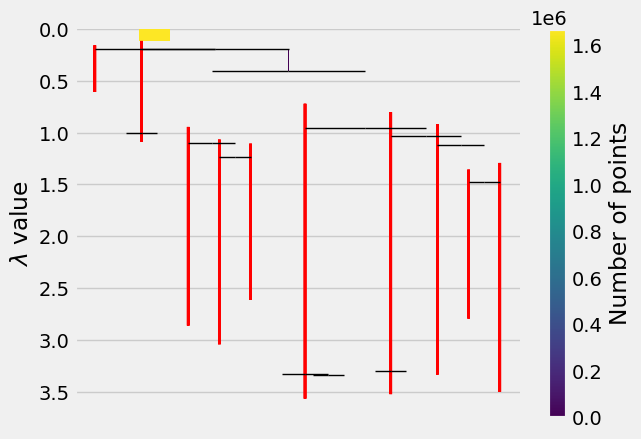

In [5]:
X = prev_app.select_dtypes(include=[np.number]).dropna(axis=1, how="all")

# X = stats_helper.clip_IQR_outliers(X, quantile=0.2, multiplier=2)
X = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)

clusterer = hdbscan.HDBSCAN(min_cluster_size=50)
labels = clusterer.fit_predict(X)
X["group"] = labels.astype(str)
print(np.unique(labels))

clusterer.condensed_tree_.plot(select_clusters=True)

In [6]:
importlib.reload(unsupervised_helper)

X.sort_values(by="group", inplace=True)
fig = unsupervised_helper.plotly_3d_pca(X, hue_col="group")
fig.show()

Plotting 3D PCA with discarded NANs


* The successful split indicates large heterogeneity in data.

Inclusion of classifier column could provide useful information for the average model.

# Aggregation

## Numerics Aggregation
All numerical columns are aggregated to catch maximum variance.

In [7]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
input_dict = {col: ["mean", "min", "max", "median"] for col in numeric_cols}

In [8]:
importlib.reload(aggregator_helper)
agg = aggregator_helper.RowAggregator(

    df=prev_app, stack_columns=["SK_ID_CURR"], agg_dict=input_dict
)

agg_numerics = agg.get_df()

agg_numerics.head()

,SK_ID_CURR,mean_AMT_ANNUITY,min_AMT_ANNUITY,max_AMT_ANNUITY,median_AMT_ANNUITY,mean_AMT_APPLICATION,min_AMT_APPLICATION,max_AMT_APPLICATION,median_AMT_APPLICATION,mean_AMT_CREDIT,...,max_DAYS_LAST_DUE,median_DAYS_LAST_DUE,mean_DAYS_TERMINATION,min_DAYS_TERMINATION,max_DAYS_TERMINATION,median_DAYS_TERMINATION,mean_NFLAG_INSURED_ON_APPROVAL,min_NFLAG_INSURED_ON_APPROVAL,max_NFLAG_INSURED_ON_APPROVAL,median_NFLAG_INSURED_ON_APPROVAL
0,100001,3951.000,3951.000,3951.000,3951.000,24835.50,24835.5,24835.5,24835.50,23787.00,...,-1619.0,-1619.0,-1612.000000,-1612.0,-1612.0,-1612.0,0.000000,0.0,0.0,0.0
1,100002,9251.775,9251.775,9251.775,9251.775,179055.00,179055.0,179055.0,179055.00,179055.00,...,-25.0,-25.0,-17.000000,-17.0,-17.0,-17.0,0.000000,0.0,0.0,0.0
2,100003,56553.990,6737.310,98356.995,64567.665,435436.50,68809.5,900000.0,337500.00,484191.00,...,-536.0,-647.0,-1047.333333,-1976.0,-527.0,-639.0,0.666667,0.0,1.0,1.0
3,100004,5357.250,5357.250,5357.250,5357.250,24282.00,24282.0,24282.0,24282.00,20106.00,...,-724.0,-724.0,-714.000000,-714.0,-714.0,-714.0,0.000000,0.0,0.0,0.0
4,100005,4813.200,4813.200,4813.200,4813.200,22308.75,0.0,44617.5,22308.75,20076.75,...,-466.0,-466.0,-460.000000,-460.0,-460.0,-460.0,0.000000,0.0,0.0,0.0


In [9]:
base = joblib.load("data/processed/aggregated_bureau.jbl")
X_train = base.merge(agg_numerics, on="SK_ID_CURR", how="left")
X_train = X_train.loc[~X_train["TARGET"].isna(), :]
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307511 entries, 48744 to 356254
Columns: 398 entries, SK_ID_CURR to median_NFLAG_INSURED_ON_APPROVAL
dtypes: bool(34), category(11), float64(342), int64(7), object(4)
memory usage: 843.7+ MB


In [10]:
submissions.cv_lgbm(X_train.drop(columns=["SK_ID_CURR"]))

,average_precision,roc_auc,f1_macro
mean,0.2607,0.7733,0.5549
std,0.0061,0.0036,0.0021


A notable improvement was achieved after inclusion of numeric features, compared to nb6:

| | average_precision | roc_auc | f1_macro |
|---|---|---|---|
| 0 | 0.2523 | 0.7648 | 0.5489 |

## Categorical Aggregation
13 unique categorical exist

In [11]:
cat_cols = prev_app.select_dtypes(include=["category"]).columns.tolist()

cat_info = []
for col in cat_cols:
    cat_info.append({"Column": col, "Unique Values": prev_app[col].nunique()})

cat_info_df = pd.DataFrame(cat_info)
display(cat_info_df)

,Column,Unique Values
0,NAME_CONTRACT_TYPE,4
1,WEEKDAY_APPR_PROCESS_START,7
2,NAME_CASH_LOAN_PURPOSE,25
3,NAME_CONTRACT_STATUS,4
4,NAME_PAYMENT_TYPE,4
5,CODE_REJECT_REASON,9
6,NAME_TYPE_SUITE,7
7,NAME_CLIENT_TYPE,4
8,NAME_GOODS_CATEGORY,28
9,NAME_PORTFOLIO,5


In [12]:
importlib.reload(aggregator_helper)
agg_cats = aggregator_helper.RowAggregator(
    df=prev_app,
    stack_columns=["SK_ID_CURR"],
    agg_dict={col: ["onehot_count"] for col in cat_cols},
)
agg_cats_df = agg_cats.get_df()
agg_cats_df.head()

,SK_ID_CURR,onehot_count_NAME_CONTRACT_TYPE_C,onehot_count_NAME_CONTRACT_TYPE_R,onehot_count_NAME_CONTRACT_TYPE_X,onehot_count_WEEKDAY_APPR_PROCESS_START_F,onehot_count_WEEKDAY_APPR_PROCESS_START_M,onehot_count_WEEKDAY_APPR_PROCESS_START_S,onehot_count_WEEKDAY_APPR_PROCESS_START_T,onehot_count_WEEKDAY_APPR_PROCESS_START_W,onehot_count_NAME_CASH_LOAN_PURPOSE_B,...,onehot_count_NAME_SELLER_INDUSTRY_F,onehot_count_NAME_SELLER_INDUSTRY_I,onehot_count_NAME_SELLER_INDUSTRY_J,onehot_count_NAME_SELLER_INDUSTRY_M,onehot_count_NAME_SELLER_INDUSTRY_T,onehot_count_NAME_SELLER_INDUSTRY_X,onehot_count_NAME_YIELD_GROUP_X,onehot_count_NAME_YIELD_GROUP_h,onehot_count_NAME_YIELD_GROUP_l,onehot_count_NAME_YIELD_GROUP_m
0,100001,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,100002,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,100003,1,0,0,1,0,1,0,0,0,...,1,0,0,0,0,1,0,0,0,2
3,100004,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,100005,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,1,1,1,0,0


These are then joined together with previous numeric columns and the result reevaluated.

In [13]:
X_train = X_train.merge(agg_cats_df, on="SK_ID_CURR", how="left")
submissions.cv_lgbm(X_train.drop(columns=["SK_ID_CURR"]))

,average_precision,roc_auc,f1_macro
mean,0.2645,0.7751,0.5566
std,0.0068,0.0038,0.0018


Inclusion of additional categorical features has significantly boosted models performance.

# Previous Application Sub-tables
Previous applications includes three lesser tables that can be used to provide further context for the model:
* `POS_CASH_balance`
* `installments_payments`
* `credit_card_balance`

## POS_CASH_balance
We once again base the analysis on initial exploration of nb2.

In [14]:
pos = preprocessing.load_pkl_to_preprocessor("POS_CASH_balance").convert_all("category")
pos.head()

Loading tables: ['POS_CASH_balance.csv']
loaded POS_CASH_balance with shape (10001358, 8)
dict_keys(['credit_status', 'bureau_overdue', 'time_variables', 'bureau', 'bureau_balance', 'pos_cash_balance', 'balance_limits', 'drawings_payments', 'contract_installments', 'credit_card_balance', 'previous_application', 'installments_payments'])
No missing columns.
Unexpected columns: ['SK_ID_CURR', 'SK_ID_PREV']
No missing columns.
Unexpected columns: ['SK_ID_CURR', 'SK_ID_PREV']


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


Given that the `SK_ID_CURR` is included in the table, aggregating the table to previous application table directly does not make sense. Aggregation of an aggregation is going to loose more informative features than just a single direct aggregation. This could be worked around with some more nuanced data assignment approaches, but for time saving scope will be avoided.

In [15]:
metrics_dict = {
    **{
        col: ["mean", "min", "max", "median"]
        for col in pos.select_dtypes(include=[np.number]).columns.tolist()
    },
    **{
        col: ["onehot_count"]
        for col in pos.select_dtypes(include=["category"]).columns.tolist()
    },
}

pos_agg = aggregator_helper.RowAggregator(
    df=pos, stack_columns=["SK_ID_CURR"], agg_dict=metrics_dict
)
pos_agg_df = pos_agg.get_df()
pos_agg_df.head()

,SK_ID_CURR,mean_SK_ID_PREV,min_SK_ID_PREV,max_SK_ID_PREV,median_SK_ID_PREV,mean_MONTHS_BALANCE,min_MONTHS_BALANCE,max_MONTHS_BALANCE,median_MONTHS_BALANCE,mean_CNT_INSTALMENT,...,mean_SK_DPD_DEF,min_SK_DPD_DEF,max_SK_DPD_DEF,median_SK_DPD_DEF,onehot_count_NAME_CONTRACT_STATUS_A,onehot_count_NAME_CONTRACT_STATUS_C,onehot_count_NAME_CONTRACT_STATUS_D,onehot_count_NAME_CONTRACT_STATUS_R,onehot_count_NAME_CONTRACT_STATUS_S,onehot_count_NAME_CONTRACT_STATUS_X
0,100001,1.584045e+06,1369693,1851984,1369693.0,-72.555556,-96,-53,-57.0,4.000000,...,0.777778,0,7,0.0,7,0,0,0,0,0
1,100002,1.038818e+06,1038818,1038818,1038818.0,-10.000000,-19,-1,-10.0,24.000000,...,0.000000,0,0,0.0,19,0,0,0,0,0
2,100003,2.297665e+06,1810518,2636178,2396755.0,-43.785714,-77,-18,-26.5,10.107143,...,0.000000,0,0,0.0,26,0,0,0,0,0
3,100004,1.564014e+06,1564014,1564014,1564014.0,-25.500000,-27,-24,-25.5,3.750000,...,0.000000,0,0,0.0,3,0,0,0,0,0
4,100005,2.495675e+06,2495675,2495675,2495675.0,-20.000000,-25,-15,-20.0,11.700000,...,0.000000,0,0,0.0,9,0,0,0,1,0


In [16]:
X_train = X_train.merge(pos_agg_df, on="SK_ID_CURR", how="left")
submissions.cv_lgbm(X_train.drop(columns=["SK_ID_CURR"]))

,average_precision,roc_auc,f1_macro
mean,0.2685,0.7773,0.5579
std,0.0065,0.0038,0.0020


A modest improvement in performance observed. 

## installments_payments

In [17]:
installments = preprocessing.load_pkl_to_preprocessor(
    "installments_payments"
).convert_all("category")
installments.head()

Loading tables: ['installments_payments.csv']


loaded installments_payments with shape (13605401, 8)
dict_keys(['credit_status', 'bureau_overdue', 'time_variables', 'bureau', 'bureau_balance', 'pos_cash_balance', 'balance_limits', 'drawings_payments', 'contract_installments', 'credit_card_balance', 'previous_application', 'installments_payments'])
No missing columns.
Unexpected columns: ['SK_ID_CURR', 'SK_ID_PREV']
No missing columns.
Unexpected columns: ['SK_ID_CURR', 'SK_ID_PREV']


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


Similar to the previous table, direct aggregation is possible.

In [18]:
metrics_dict = {
    **{
        col: ["mean", "min", "max", "median"]
        for col in installments.select_dtypes(include=[np.number]).columns.tolist()
    },
    **{
        col: ["onehot_count"]
        for col in installments.select_dtypes(include=["category"]).columns.tolist()
    },
}

installments_agg = aggregator_helper.RowAggregator(
    df=installments, stack_columns=["SK_ID_CURR"], agg_dict=metrics_dict
)
installments_agg_df = installments_agg.get_df()
installments_agg_df.head()

,SK_ID_CURR,mean_SK_ID_PREV,min_SK_ID_PREV,max_SK_ID_PREV,median_SK_ID_PREV,mean_NUM_INSTALMENT_VERSION,min_NUM_INSTALMENT_VERSION,max_NUM_INSTALMENT_VERSION,median_NUM_INSTALMENT_VERSION,mean_NUM_INSTALMENT_NUMBER,...,max_DAYS_ENTRY_PAYMENT,median_DAYS_ENTRY_PAYMENT,mean_AMT_INSTALMENT,min_AMT_INSTALMENT,max_AMT_INSTALMENT,median_AMT_INSTALMENT,mean_AMT_PAYMENT,min_AMT_PAYMENT,max_AMT_PAYMENT,median_AMT_PAYMENT
0,100001,1.576389e+06,1369693,1851984,1369693.0,1.142857,1.0,2.0,1.0,2.714286,...,-1628.0,-1715.0,5885.132143,3951.000,17397.900,3980.925,5885.132143,3951.000,17397.900,3980.925
1,100002,1.038818e+06,1038818,1038818,1038818.0,1.052632,1.0,2.0,1.0,10.000000,...,-49.0,-312.0,11559.247105,9251.775,53093.745,9251.775,11559.247105,9251.775,53093.745,9251.775
2,100003,2.290070e+06,1810518,2636178,2396755.0,1.040000,1.0,2.0,1.0,5.080000,...,-544.0,-806.0,64754.586000,6662.970,560835.360,64275.615,64754.586000,6662.970,560835.360,64275.615
3,100004,1.564014e+06,1564014,1564014,1564014.0,1.333333,1.0,2.0,1.0,2.000000,...,-727.0,-763.0,7096.155000,5357.250,10573.965,5357.250,7096.155000,5357.250,10573.965,5357.250
4,100005,2.495675e+06,2495675,2495675,2495675.0,1.111111,1.0,2.0,1.0,5.000000,...,-470.0,-585.0,6240.205000,4813.200,17656.245,4813.200,6240.205000,4813.200,17656.245,4813.200


In [19]:
X_train = X_train.merge(installments_agg_df, on="SK_ID_CURR", how="left")
submissions.cv_lgbm(X_train.drop(columns=["SK_ID_CURR"]))

,average_precision,roc_auc,f1_macro
mean,0.2704,0.7789,0.5594
std,0.0069,0.0038,0.0020


Although limited, improvement was observed

## credit_card_balance
The approach is identical

In [20]:
credit = preprocessing.load_pkl_to_preprocessor(
    "credit_card_balance"
).convert_all("category")
credit.head()

Loading tables: ['credit_card_balance.csv']
loaded credit_card_balance with shape (3840312, 23)
dict_keys(['credit_status', 'bureau_overdue', 'time_variables', 'bureau', 'bureau_balance', 'pos_cash_balance', 'balance_limits', 'drawings_payments', 'contract_installments', 'credit_card_balance', 'previous_application', 'installments_payments'])
No missing columns.
Unexpected columns: ['SK_ID_CURR', 'SK_ID_PREV']
No missing columns.
Unexpected columns: ['SK_ID_CURR', 'SK_ID_PREV']


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [21]:
metrics_dict = {
    **{
        col: ["mean", "min", "max", "median"]
        for col in credit.select_dtypes(include=[np.number]).columns.tolist()
    },
    **{
        col: ["onehot_count"]
        for col in credit.select_dtypes(include=["category"]).columns.tolist()
    },
}

credit_agg = aggregator_helper.RowAggregator(
    df=credit, stack_columns=["SK_ID_CURR"], agg_dict=metrics_dict
)
credit_agg_df = credit_agg.get_df()
credit_agg_df.head()

,SK_ID_CURR,mean_SK_ID_PREV,min_SK_ID_PREV,max_SK_ID_PREV,median_SK_ID_PREV,mean_MONTHS_BALANCE,min_MONTHS_BALANCE,max_MONTHS_BALANCE,median_MONTHS_BALANCE,mean_AMT_BALANCE,...,median_SK_DPD,mean_SK_DPD_DEF,min_SK_DPD_DEF,max_SK_DPD_DEF,median_SK_DPD_DEF,onehot_count_NAME_CONTRACT_STATUS_A,onehot_count_NAME_CONTRACT_STATUS_C,onehot_count_NAME_CONTRACT_STATUS_D,onehot_count_NAME_CONTRACT_STATUS_R,onehot_count_NAME_CONTRACT_STATUS_S
0,100006,1489396.0,1489396,1489396,1489396.0,-3.5,-6,-1,-3.5,0.000000,...,0.0,0.000000,0,0,0.0,6,0,0,0,0
1,100011,1843384.0,1843384,1843384,1843384.0,-38.5,-75,-2,-38.5,54482.111149,...,0.0,0.000000,0,0,0.0,74,0,0,0,0
2,100013,2038692.0,2038692,2038692,2038692.0,-48.5,-96,-1,-48.5,18159.919219,...,0.0,0.010417,0,1,0.0,96,0,0,0,0
3,100021,2594025.0,2594025,2594025,2594025.0,-10.0,-18,-2,-10.0,0.000000,...,0.0,0.000000,0,0,0.0,7,10,0,0,0
4,100023,1499902.0,1499902,1499902,1499902.0,-7.5,-11,-4,-7.5,0.000000,...,0.0,0.000000,0,0,0.0,8,0,0,0,0


In [22]:
X_train = X_train.merge(credit_agg_df, on="SK_ID_CURR", how="left")
submissions.cv_lgbm(X_train.drop(columns=["SK_ID_CURR"]))

,average_precision,roc_auc,f1_macro
mean,0.2731,0.7810,0.5613
std,0.0049,0.0034,0.0018


* Only minor model improvement was achieved.
The table requires deeper analysis.

# Conclusions

## Workflow integration
The modified base is saved to simplify further workflow.

In [44]:
save = base.merge(pos_agg_df, on="SK_ID_CURR", how="left")
save = save.merge(installments_agg_df, on="SK_ID_CURR", how="left")
save = save.merge(credit_agg_df, on="SK_ID_CURR", how="left")

for col in ["CODE_GENDER", "NAME_INCOME_TYPE", "NAME_FAMILY_STATUS"]:
    save[col] = save[col].astype("category")


joblib.dump(base, "data/processed/all_tables.jbl")

save.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356255 entries, 0 to 356254
Columns: 473 entries, SK_ID_CURR to onehot_count_NAME_CONTRACT_STATUS_S_y
dtypes: bool(34), category(14), float64(417), int64(7), object(1)
memory usage: 1.1+ GB


## Model confirmation

In [46]:
X_train = save[~save['TARGET'].isna()]
y_train = save["TARGET"].dropna()
X_test = save[save['TARGET'].isna()]


submissions.lgbm_submission(
    X_train, y_train, X_test, "all_tables"
)

Submission created: submissions\sub_2025-08-05_11-52_all_tables.csv


'submissions\\sub_2025-08-05_11-52_all_tables.csv'

* Public score was increased to 0.76818 whereas private score boosted to (0.77151)
This indicates that the model slightly overfit on the training data. Moreover, it appears that the performance is split dependant.
